In [1]:
# Cell 1: Imports and data loading
import sys
import os
sys.path.append('..')

import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, roc_curve
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from src.features import compute_woe_iv
from src.modeling import woe_encode

df = pd.read_csv("../outputs/loan_book_clean.csv")
train = df[df["set"] == "train"].copy()
test = df[df["set"] == "test"].copy()

print(f"Train: {len(train)} rows | Test: {len(test)} rows")

2026-05-21 16:23:43.505 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-21 16:23:43.505 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-21 16:23:43.588 
  command:

    streamlit run /Users/tshilidzivhengani/PycharmProjects/DataQuest_2026/.venv/lib/python3.13/site-packages/ipykernel_launcher.py [ARGUMENTS]
2026-05-21 16:23:43.589 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-21 16:23:43.590 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-21 16:23:43.590 No runtime found, using MemoryCacheStorageManager
2026-05-21 16:23:43.591 No runtime found, using MemoryCacheStorageManager
2026-05-21 16:23:43.591 Thread 'MainTh

Train: 84264 rows | Test: 36080 rows


In [2]:
# Cell 2: Prepare features for baseline
baseline_features = [
    "age", "annual_income", "employment_length_years",
    "num_open_accounts", "num_delinquencies_2yr",
    "total_revolving_balance", "credit_utilisation_pct",
    "months_since_oldest_account", "num_hard_inquiries_6mo",
    "loan_amount", "interest_rate", "dti_ratio",
    "months_since_last_delinquency", "pct_accounts_current",
    "months_at_current_address"
]

X_train = train[baseline_features]
y_train = train["default_flag"]

X_test = test[baseline_features]
y_test = test["default_flag"]

print(f"Features: {len(baseline_features)}")
print(f"X_train shape: {X_train.shape}")

Features: 15
X_train shape: (84264, 15)


In [3]:
# Cell 3: Scale and fit
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

baseline_model = LogisticRegression(max_iter=1000, random_state=42)
baseline_model.fit(X_train_scaled, y_train)

# Predict probabilities on test set
y_pred_proba = baseline_model.predict_proba(X_test_scaled)[:,1]

baseline_auc = roc_auc_score(y_test, y_pred_proba)
print(f"Baseline AUC: {baseline_auc}")

Baseline AUC: 0.7886886539778454


## Baseline Model

**Approach:** All 15 numeric features were used, as well as scaling but no feature engineering.

**Result:** Baseline AUC: 0.7886886539778454 (0.789)

**Note:** An older model had an AUC of 0.68, this baseline model is higher because the data was carefully cleaned (categorical normalisation, sensible missing value handling for months_since_last_delinquency, outlier capping) and I included all available numeric features into the model. The next step is to use feature engineering to hopefully beat 0.789

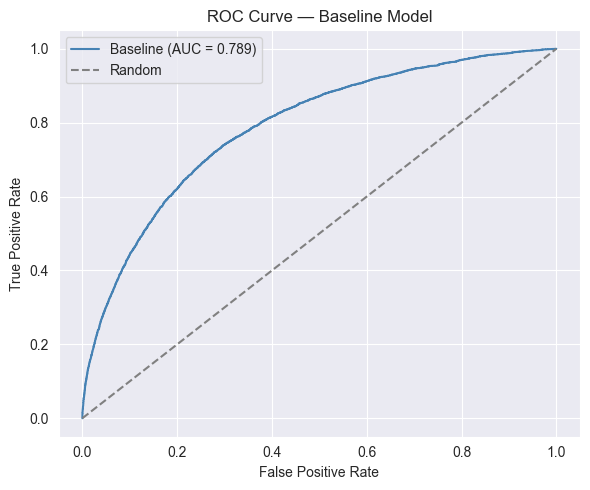

In [4]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color="steelblue", label=f"Baseline (AUC = {baseline_auc:.3f})")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Baseline Model")
ax.legend()
plt.tight_layout()
plt.show()

In [5]:
# Build WoE-encoded features
# Top features from EDA (already monotonic)
raw_features = [
    "interest_rate",
    "months_since_last_delinquency",
    "age",
    "num_delinquencies_2yr",
    "employment_length_years",
    "pct_accounts_current",
    "dti_ratio",
]

woe_features = [
    "annual_income",
]

scaler = StandardScaler()
X_train_improved = pd.DataFrame(
    scaler.fit_transform(train[raw_features]),
    columns=[f"{c}_scaled" for c in raw_features],
    index=train.index
)
X_test_improved = pd.DataFrame(
    scaler.transform(test[raw_features]),
    columns=[f"{c}_scaled" for c in raw_features],
    index=test.index
)

for feat in woe_features:
    train_woe, test_woe = woe_encode(train[feat], test[feat], train["default_flag"])
    X_train_improved[f"{feat}_woe"] = train_woe.values
    X_test_improved[f"{feat}_woe"] = test_woe.values

print(f"Features: {list(X_train_improved.columns)}")
print(f"Shape: {X_train_improved.shape}")

Features: ['interest_rate_scaled', 'months_since_last_delinquency_scaled', 'age_scaled', 'num_delinquencies_2yr_scaled', 'employment_length_years_scaled', 'pct_accounts_current_scaled', 'dti_ratio_scaled', 'annual_income_woe']
Shape: (84264, 8)


In [6]:
# Add the interaction feature
# Income and interest rate interaction
X_train_improved["income_rate_interaction"] = train["annual_income"] / (train["interest_rate"] + 1)
X_test_improved["income_rate_interaction"] = test["annual_income"] / (test["interest_rate"] + 1)

interaction_scaler = StandardScaler()
X_train_improved["income_rate_interaction"] = interaction_scaler.fit_transform(X_train_improved[["income_rate_interaction"]])
X_test_improved["income_rate_interaction"] = interaction_scaler.transform(X_test_improved[["income_rate_interaction"]])

print(f"Final feature count: {X_train_improved.shape[1]}")
print(f"Features: {list(X_train_improved.columns)}")

Final feature count: 9
Features: ['interest_rate_scaled', 'months_since_last_delinquency_scaled', 'age_scaled', 'num_delinquencies_2yr_scaled', 'employment_length_years_scaled', 'pct_accounts_current_scaled', 'dti_ratio_scaled', 'annual_income_woe', 'income_rate_interaction']


In [8]:
# Handle any NaN values from WoE encoding
print("NaN counts:")
print(X_train_improved.isna().sum().sum(), "train")
print(X_test_improved.isna().sum().sum(), "test")

X_train_improved = X_train_improved.fillna(0)
X_test_improved = X_test_improved.fillna(0)

NaN counts:
0 train
0 test


In [9]:
# Fit the improved model and compare
improved_model = LogisticRegression(max_iter=1000, random_state=42)
improved_model.fit(X_train_improved, y_train)

y_pred_improved = improved_model.predict_proba(X_test_improved)[:,1]
improved_auc = roc_auc_score(y_test, y_pred_improved)

print(f"\nBaseline AUC: {baseline_auc:.4f}")
print(f"Improved AUC: {improved_auc:.4f}")
print(f"Improved AUC: {(improved_auc - baseline_auc):.4f}")


Baseline AUC: 0.7887
Improved AUC: 0.7767
Improved AUC: -0.0120
